**1: Preparação do Ambiente**

In [1]:
# Célula 1: Setup do Ambiente de Avaliação e Produção
from google.colab import drive
drive.mount('/content/drive')

# 1. Ignoramos o aviso de remoção do wandb
!pip uninstall -y wandb

# 2. Atualizamos o torchao para o carregamento do LoRA
!pip install -q -U torchao

# 3. A Engrenagem: versão 8.1.8 que compatível com o Google Colab e o gTTS
!pip install -q click==8.1.8

# 4. Instalamos o nosso Stack Multimodal
!pip install -q diffusers transformers accelerate torchmetrics[image] gradio gTTS huggingface_hub peft

print("✅ Ambiente de produção preparado com sucesso!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Ambiente de produção preparado com sucesso!


**2: (Etapa 3) — Avaliação Matemática (CLIPScore)**

Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Carregando o Modelo Base (SD 1.5)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

...

Carregando o Avaliador Matemático (CLIP)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


🎨 Gerando imagens para avaliação com o prompt:
'estilo_pixel_art, cena em pixel art de um lago, coqueiros e um barco.'



  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

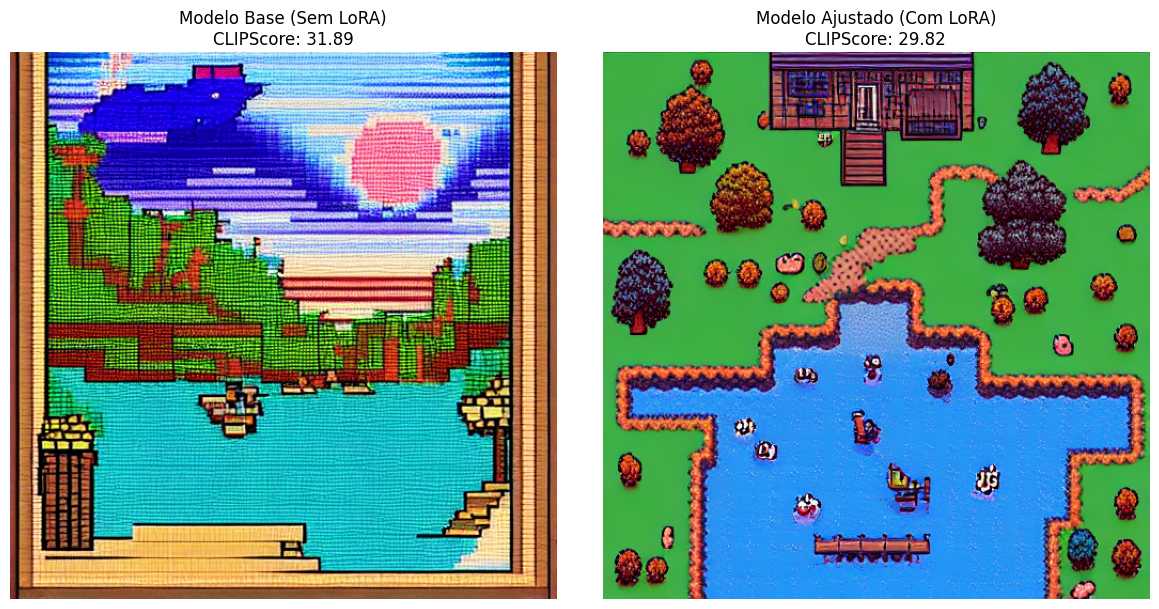

In [2]:
# Célula 2: Cálculo do CLIPScore e Teste A/B Visual
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from diffusers import StableDiffusionPipeline
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Carregamento dos Modelos de Difusão (Base e LoRA)
print("Carregando o Modelo Base (SD 1.5)...")
pipe_base = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to(device)

print("Carregando o Modelo Ajustado (LoRA)...")
pipe_lora = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to(device)
caminho_lora = "/content/drive/MyDrive/Atelie_Generativo_LoRA/PixelArt_Rank32"
pipe_lora.load_lora_weights(caminho_lora)

# 2. Carregamento Explícito do Avaliador CLIP
print("Carregando o Avaliador Matemático (CLIP)...")
clip_id = "openai/clip-vit-base-patch16"
processor = CLIPProcessor.from_pretrained(clip_id)
clip_model = CLIPModel.from_pretrained(clip_id).to(device)

# 3. Geração das Imagens (Teste A/B)
prompt_avaliacao = "estilo_pixel_art, cena em pixel art de um lago, coqueiros e um barco."
print(f"\n🎨 Gerando imagens para avaliação com o prompt:\n'{prompt_avaliacao}'\n")

gerador_seed = torch.manual_seed(42) # Seed fixa para o teste ser justo
img_base = pipe_base(prompt_avaliacao, num_inference_steps=30, generator=gerador_seed).images[0]
img_lora = pipe_lora(prompt_avaliacao, num_inference_steps=30, generator=gerador_seed).images[0]

# 4. Implementação Matemática do CLIPScore (Similaridade de Cossenos)
def calcular_clip_score_robusto(imagem, texto):
    # Transforma a imagem e o texto em tensores compreensíveis pelo CLIP
    inputs = processor(text=[texto], images=imagem, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()} # Envia para a GPU

    with torch.no_grad():
        # Passa pelo modelo
        outputs = clip_model(**inputs)
        # Extrai os vetores matemáticos puros (Embeddings)
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds

    # Calcula a distância entre os vetores (Cosseno) e multiplica por 100 (Padrão da métrica)
    cosine_sim = F.cosine_similarity(image_embeds, text_embeds)
    return (cosine_sim.item() * 100)

# Calculando...
score_base = calcular_clip_score_robusto(img_base, prompt_avaliacao)
score_lora = calcular_clip_score_robusto(img_lora, prompt_avaliacao)

# 5. Exibição do Relatório Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_base)
axes[0].set_title(f"Modelo Base (Sem LoRA)\nCLIPScore: {score_base:.2f}")
axes[0].axis("off")

axes[1].imshow(img_lora)
axes[1].set_title(f"Modelo Ajustado (Com LoRA)\nCLIPScore: {score_lora:.2f}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

👨‍🏫 Avaliação Humana e Overfitting:
> Overfitting: O modelo decorou os dados ou aprendeu o estilo? Analisem a imagem gerada pelo LoRA. Se ela for idêntica a uma das fotos do dataset, houve memorização (overfitting). Se for uma cena nova, mas com a "vibe" do Pixel Art, houve generalização bem-sucedida!



**3: O "Shift" para Cloud (Subindo o modelo para o Hugging Face Hub)**

In [4]:
# Célula 3: Publicação do Modelo (Weights) no Hugging Face Hub
from huggingface_hub import HfApi, login

print("🔑 Faça o login com o seu Token de ESCRITA (Write Token) do Hugging Face:")
login() # Um prompt aparecerá para você colar o token (não escreva no código!)

# Substitua pelas suas credenciais
SEU_USUARIO_HF = "roderiok" # Coloque seu usuário real aqui
NOME_DO_MODELO = "pixelart-16bit-lora"

api = HfApi()
repo_id = f"{SEU_USUARIO_HF}/{NOME_DO_MODELO}"

print(f"🚀 Criando repositório público: {repo_id}...")
api.create_repo(repo_id=repo_id, exist_ok=True)

print("⏳ Enviando os pesos do LoRA. Isso pode levar alguns minutos...")
api.upload_folder(
    folder_path=caminho_lora, # A pasta do Drive com o rank32
    repo_id=repo_id,
    repo_type="model"
)
print("✅ LoRA publicado com sucesso no Hugging Face Hub!")

🔑 Faça o login com o seu Token de ESCRITA (Write Token) do Hugging Face:
🚀 Criando repositório público: roderiok/pixelart-16bit-lora...
⏳ Enviando os pesos do LoRA. Isso pode levar alguns minutos...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ckpoint-500/scheduler.bin: 100%|##########| 1.40kB / 1.40kB            

  .../checkpoint-500/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

...

  ..._lora_weights.safetensors: 100%|##########| 25.5MB / 25.5MB            

  ...ckpoint-500/optimizer.bin:  16%|#5        | 7.99MB / 51.2MB            

  ...kpoint-1000/optimizer.bin:  16%|#5        | 7.98MB / 51.2MB            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ LoRA publicado com sucesso no Hugging Face Hub!


**4: (Etapa 4) — Desenvolvimento do Pipeline Multimodal Web**

In [5]:
# Célula 4: Construção da Estrutura do App (Infraestrutura as Code)
import os

app_dir = "/content/meu_app_espaco"
os.makedirs(app_dir, exist_ok=True)

# 1. Criação do requirements.txt
with open(os.path.join(app_dir, "requirements.txt"), "w") as f:
    f.write("gradio\ndiffusers\ntransformers\naccelerate\ntorch\ngTTS\npeft\n")

# 2. Criação do app.py (O Pipeline Multimodal)
app_code = """
import gradio as gr
import torch
from diffusers import StableDiffusionPipeline
from gtts import gTTS
import os

# Configuração dinâmica: Usa GPU se disponível no Spaces (ex: ZeroGPU), senão cai para CPU (Inference via software)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print(f"Inicializando modelo no dispositivo: {device}")
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch_dtype).to(device)

# Carrega o LoRA usando a Inference API
pipe.load_lora_weights("roderiok/pixelart-16bit-lora")

def gerar_experiencia_multimodal(prompt_usuario):
    # Modalidade 1: Orquestração do Texto
    prompt_orquestrado = f"estilo_pixel_art, {prompt_usuario}, cena em pixel art de um lago, coqueiros e um barco."

    # Modalidade 2: Visão Computacional (Geração da Imagem)
    # 20 steps garantem rapidez no ambiente sem GPU dedicada (como o Spaces gratuito)
    imagem = pipe(prompt_orquestrado, num_inference_steps=30, guidance_scale=7.5, cross_attention_kwargs={"scale": 0.7}).images[0]

    # Modalidade 3: Síntese de Áudio
    texto_narracao = f"Gerando arte em pixel art para a sua solicitação: {prompt_usuario}."
    tts = gTTS(texto_narracao, lang='pt')
    audio_path = "narracao.mp3"
    tts.save(audio_path)

    return prompt_orquestrado, imagem, audio_path

# Interface UI/UX
with gr.Blocks(theme=gr.themes.Base()) as demo:
    gr.Markdown("# 👾 Ateliê Generativo: Multimodal Pixel Art (16-bits)")
    gr.Markdown("Transforme suas ideias em arte retrô narrada. Pipeline Integrado: Texto ➔ Imagem ➔ Áudio.")

    with gr.Row():
        with gr.Column(scale=1):
            entrada = gr.Textbox(label="O que você deseja criar?", placeholder="Ex: Cena em pixel art de um lago, coqueiros e um barco.")
            btn = gr.Button("Sintetizar", variant="primary")
            saida_prompt = gr.Textbox(label="Texto Orquestrado", interactive=False)
            saida_audio = gr.Audio(label="Voz do Sistema")

        with gr.Column(scale=2):
            saida_imagem = gr.Image(label="Arte Gerada")

    btn.click(fn=gerar_experiencia_multimodal, inputs=entrada, outputs=[saida_prompt, saida_imagem, saida_audio])

demo.launch()
"""

with open(os.path.join(app_dir, "app.py"), "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ Arquivos atualizados com sucesso!")

✅ Arquivos atualizados com sucesso!


**5: Deploy Final no Hugging Face Spaces (O "Go Live")**

**⚠️ Gestão de Chaves e Segurança:**
> Como estamos submetendo via API e usando as variáveis nativas do Hugging Face, os tokens estão criptografados.



In [6]:
# Célula 5: Deploy da Aplicação no Hugging Face Spaces
from huggingface_hub import HfApi

api = HfApi()
repo_space_id = f"{SEU_USUARIO_HF}/atelie-multimodal-pixelart"

print(f"🚀 Criando o Servidor (Space) público: {repo_space_id}...")
# Criamos um Space com o SDK do Gradio
api.create_repo(repo_id=repo_space_id, repo_type="space", space_sdk="gradio", exist_ok=True)

print("⏳ Fazendo o Deploy dos arquivos da aplicação. Aguarde...")
api.upload_folder(
    folder_path=app_dir,
    repo_id=repo_space_id,
    repo_type="space"
)

print(f"🎉 DEPLOY CONCLUÍDO! Acesse sua aplicação web em: https://huggingface.co/spaces/{repo_space_id}")

🚀 Criando o Servidor (Space) público: roderiok/atelie-multimodal-pixelart...
⏳ Fazendo o Deploy dos arquivos da aplicação. Aguarde...
🎉 DEPLOY CONCLUÍDO! Acesse sua aplicação web em: https://huggingface.co/spaces/roderiok/atelie-multimodal-pixelart


🏆 Validação do Resultado

> Após executar a Célula 5, clique no link gerado e vá para a aba Files and versions no seu Space para conferir se o app.py está lá. O Space levará alguns minutos no estado Building (Construindo a imagem Docker). Assim que ficar Running, o seu pipeline multimodal estará acessível para avaliação!

